In [4]:
import pandas as pd
import glob

folder_path = "../data/attack/compromised-scada/attack logs/**/*.csv"

distinct_values = set()

for file in glob.glob(folder_path):
    df = pd.read_csv(file)
    distinct_values.update(df["TargetIP"].dropna().unique())

print(distinct_values)

{'185.175.0.5', '185.175.0.4', '185.175.0.8'}


In [5]:
folder_path = "../data/attack/compromised-ied/attack logs/**/*.csv"

distinct_values = set()

for file in glob.glob(folder_path):
    df = pd.read_csv(file)
    distinct_values.update(df["TargetIP"].dropna().unique())

print(distinct_values)

{'185.175.0.2'}


In [ ]:
folder_path = "../data/attack/external/external-attacker/attacker logs/**/*.csv"

distinct_values = set() 

for file in glob.glob(folder_path):
    df = pd.read_csv(file)
    distinct_values.update(df["Attack"].dropna().unique())

print(distinct_values)

{'Replay', 'Recon. Range: 65535', 'Payload injection - Complete', 'Stacked Modbus Frames - Complete', 'Recon. Range: 9', 'Replay - Complete', 'Recon. Range: 2', 'Length manipulation - Complete', 'Brute force or specific - Complete', 'Stacked Modbus Frames', 'Payload injection', 'Query flooding. Complete', 'Recon. Range: 1', 'Recon. Range: 20', 'Length manipulation', 'Recon. Range: 4', 'Brute force or specific coil. Address: 0', 'Query Flooding', 'Recon. Complete', 'Brute force or specific coil. Address: 13', 'Recon. Range: 5'}


In [5]:
import ipaddress
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

READ_FUNCTION_CODES = {1, 2, 3, 4}
WRITE_FUNCTION_CODES = {5, 6, 15, 16}
EXCEPTION_FUNCTION_CODES = {129, 130, 131, 132, 133, 134, 135, 136}


def _load_csv_file(input_csv):
    input_path = Path(input_csv)
    if not input_path.exists():
        raise FileNotFoundError(f"Input CSV not found: {input_path}")
    if input_path.suffix.lower() != ".csv":
        raise ValueError(f"Input file must be a CSV: {input_path}")

    combined = pd.read_csv(input_path)
    combined["source_file"] = input_path.name
    return combined, input_path


def _prepare_ip_window(input_csv, ip_address, timestamp, time_range_seconds, time_offset_seconds=0):
    ipaddress.ip_address(ip_address)

    combined, input_path = _load_csv_file(input_csv)

    required_cols = {"ip.src", "ip.dst", "frame.time_epoch"}
    missing = required_cols - set(combined.columns)
    if missing:
        raise ValueError(f"Missing required column(s): {sorted(missing)}")

    frame_epoch = pd.to_numeric(combined["frame.time_epoch"], errors="coerce")
    combined = combined.loc[frame_epoch.notna()].copy()
    combined["aligned_epoch"] = frame_epoch[frame_epoch.notna()] + float(time_offset_seconds)
    combined["aligned_ts"] = pd.to_datetime(combined["aligned_epoch"], unit="s", errors="coerce")
    combined = combined.dropna(subset=["aligned_ts"]).copy()

    target_ts = pd.to_datetime(timestamp, errors="raise")
    window_start = target_ts - pd.Timedelta(seconds=time_range_seconds)
    window_end = target_ts + pd.Timedelta(seconds=time_range_seconds)
    target_second = target_ts.floor("s")

    src = combined["ip.src"].fillna("").astype(str)
    dst = combined["ip.dst"].fillna("").astype(str)
    ip_df = combined[(src == ip_address) | (dst == ip_address)].copy()
    ip_df = ip_df.sort_values("aligned_ts")

    window_df = ip_df[(ip_df["aligned_ts"] >= window_start) & (ip_df["aligned_ts"] <= window_end)].copy()
    window_df = window_df.sort_values("aligned_ts")
    if not window_df.empty:
        window_df["second_bin"] = window_df["aligned_ts"].dt.floor("s")

    plot_bins = pd.date_range(
        start=target_second - pd.Timedelta(seconds=time_range_seconds),
        end=target_second + pd.Timedelta(seconds=time_range_seconds),
        freq="s",
    )

    return {
        "combined": combined,
        "input_path": input_path,
        "ip_df": ip_df,
        "window_df": window_df,
        "target_ts": target_ts,
        "window_start": window_start,
        "window_end": window_end,
        "target_second": target_second,
        "plot_bins": plot_bins,
    }


def _debug_window_summary(context, ip_address, attack_name, time_range_seconds, time_offset_seconds, metric_name):
    window_df = context["window_df"]
    ip_df = context["ip_df"]
    target_ts = context["target_ts"]
    window_start = context["window_start"]
    window_end = context["window_end"]
    input_path = context["input_path"]

    print(f"Attack name: {attack_name}")
    print(f"Input CSV: {input_path}")
    print(f"Input rows: {len(context['combined'])}")
    print(f"Rows for IP {ip_address}: {len(ip_df)}")
    print(f"Window: {window_start} -> {window_end}")
    print(f"Rows in ±{time_range_seconds} second window: {len(window_df)}")
    print(f"Time offset applied: {time_offset_seconds} seconds")
    print(f"Metric: {metric_name}")
    print(f"Target timestamp: {target_ts}")

    if not window_df.empty:
        print(f"Window start in data: {window_df['aligned_ts'].min()}")
        print(f"Window end in data:   {window_df['aligned_ts'].max()}")
    else:
        print("No rows in requested window.")
        print(f"IP time range in this data: {ip_df['aligned_ts'].min()} -> {ip_df['aligned_ts'].max()}")

    if not ip_df.empty:
        abs_delta_s = (ip_df["aligned_ts"] - target_ts).abs().dt.total_seconds()
        nearest_idx = abs_delta_s.idxmin()
        nearest_row = ip_df.loc[nearest_idx]
        print("Nearest packet for this IP:")
        print(nearest_row[[c for c in ["aligned_ts", "frame.time_epoch", "ip.src", "ip.dst", "frame.len", "modbus.func_code", "modbus.exception_code"] if c in ip_df.columns]].to_string())
        print(f"Absolute time delta (s): {abs_delta_s.loc[nearest_idx]:.6f}")


def _build_directional_series(window_df, plot_bins, target_ip, value_column=None, value_transform=None, filter_mask=None):
    if window_df.empty:
        return (
            pd.Series(0, index=plot_bins, dtype=float),
            pd.Series(0, index=plot_bins, dtype=float),
        )

    tx_df = window_df[window_df["ip.src"].astype(str) == target_ip].copy()
    rx_df = window_df[window_df["ip.dst"].astype(str) == target_ip].copy()

    if filter_mask is not None:
        tx_df = tx_df[filter_mask(tx_df)]
        rx_df = rx_df[filter_mask(rx_df)]

    def _aggregate(frame):
        if frame.empty:
            return pd.Series(0, index=plot_bins, dtype=float)
        series = frame.groupby("second_bin").size()
        return series.reindex(plot_bins, fill_value=0).astype(float)

    if value_column is not None:

        def _aggregate_sum(frame):
            if frame.empty:
                return pd.Series(0, index=plot_bins, dtype=float)
            values = pd.to_numeric(frame[value_column], errors="coerce").fillna(0)
            frame = frame.assign(_value=values)
            if value_transform is not None:
                frame = value_transform(frame)
            series = frame.groupby("second_bin")["_value"].sum()
            return series.reindex(plot_bins, fill_value=0).astype(float)

        return _aggregate_sum(tx_df), _aggregate_sum(rx_df)

    return _aggregate(tx_df), _aggregate(rx_df)


def _plot_directional_series(plot_bins, target_second, tx_series, rx_series, title, ylabel, attack_name, ip_address, time_range_seconds):
    rel_x = (plot_bins - target_second).total_seconds().astype(int)
    fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

    axes[0].plot(rel_x, tx_series.values, label="TX (ip.src == target_ip)", marker="o")
    axes[0].axvline(0, color="black", linestyle="--", linewidth=1, label="Target timestamp")
    axes[0].set_ylabel(ylabel)
    axes[0].set_title(f"TX {title} | {attack_name} | {ip_address} (±{time_range_seconds} seconds)")
    axes[0].legend()
    axes[0].grid(alpha=0.25)

    axes[1].plot(rel_x, rx_series.values, label="RX (ip.dst == target_ip)", marker="o")
    axes[1].axvline(0, color="black", linestyle="--", linewidth=1, label="Target timestamp")
    axes[1].set_xlabel("Seconds offset from target timestamp")
    axes[1].set_ylabel(ylabel)
    axes[1].set_title("RX")
    axes[1].legend()
    axes[1].grid(alpha=0.25)

    plt.tight_layout()
    plt.show()


def plot_packet_counts_per_second(input_csv, ip_address, timestamp, attack_name, time_range_seconds, debug=False, time_offset_seconds=0):
    context = _prepare_ip_window(input_csv, ip_address, timestamp, time_range_seconds, time_offset_seconds)
    window_df = context["window_df"]
    plot_bins = context["plot_bins"]
    target_second = context["target_second"]

    tx_counts, rx_counts = _build_directional_series(window_df, plot_bins, ip_address)
    _plot_directional_series(plot_bins, target_second, tx_counts, rx_counts, "Packet counts per second", "Packet count", attack_name, ip_address, time_range_seconds)

    if debug:
        _debug_window_summary(context, ip_address, attack_name, time_range_seconds, time_offset_seconds, "Packet counts per second")
        print(f"TX packet total: {int(tx_counts.sum())}")
        print(f"RX packet total: {int(rx_counts.sum())}")
        print(f"TX peak per second: {int(tx_counts.max())}")
        print(f"RX peak per second: {int(rx_counts.max())}")

    return window_df


def plot_payload_bytes_per_second(input_csv, ip_address, timestamp, attack_name, time_range_seconds, debug=False, time_offset_seconds=0):
    context = _prepare_ip_window(input_csv, ip_address, timestamp, time_range_seconds, time_offset_seconds)
    window_df = context["window_df"]
    plot_bins = context["plot_bins"]
    target_second = context["target_second"]

    if "frame.len" not in window_df.columns:
        raise ValueError("Missing required column for byte-length plot: frame.len")

    tx_bytes, rx_bytes = _build_directional_series(window_df, plot_bins, ip_address, value_column="frame.len")
    _plot_directional_series(plot_bins, target_second, tx_bytes, rx_bytes, "Payload bytes per second", "Bytes", attack_name, ip_address, time_range_seconds)

    if debug:
        _debug_window_summary(context, ip_address, attack_name, time_range_seconds, time_offset_seconds, "Payload bytes per second")
        print(f"TX byte total: {int(tx_bytes.sum())}")
        print(f"RX byte total: {int(rx_bytes.sum())}")
        print(f"TX peak bytes per second: {int(tx_bytes.max())}")
        print(f"RX peak bytes per second: {int(rx_bytes.max())}")

    return window_df


def plot_write_function_codes_per_second(input_csv, ip_address, timestamp, attack_name, time_range_seconds, debug=False, time_offset_seconds=0):
    context = _prepare_ip_window(input_csv, ip_address, timestamp, time_range_seconds, time_offset_seconds)
    window_df = context["window_df"]
    plot_bins = context["plot_bins"]
    target_second = context["target_second"]

    if "modbus.func_code" not in window_df.columns:
        raise ValueError("Missing required column for function-code plot: modbus.func_code")

    def _is_write(frame):
        codes = pd.to_numeric(frame["modbus.func_code"], errors="coerce")
        return codes.isin(WRITE_FUNCTION_CODES)

    tx_write, rx_write = _build_directional_series(window_df, plot_bins, ip_address, filter_mask=_is_write)
    _plot_directional_series(plot_bins, target_second, tx_write, rx_write, "Write function codes per second", "Count", attack_name, ip_address, time_range_seconds)

    if debug:
        _debug_window_summary(context, ip_address, attack_name, time_range_seconds, time_offset_seconds, "Write function codes per second")
        write_codes = pd.to_numeric(window_df.get("modbus.func_code"), errors="coerce")
        print(f"Write function codes in data: {sorted(WRITE_FUNCTION_CODES)}")
        print(f"TX write-code total: {int(tx_write.sum())}")
        print(f"RX write-code total: {int(rx_write.sum())}")
        print(f"Unique write codes present: {sorted(write_codes[write_codes.isin(WRITE_FUNCTION_CODES)].dropna().unique().tolist())}")

    return window_df


def plot_read_function_codes_per_second(input_csv, ip_address, timestamp, attack_name, time_range_seconds, debug=False, time_offset_seconds=0):
    context = _prepare_ip_window(input_csv, ip_address, timestamp, time_range_seconds, time_offset_seconds)
    window_df = context["window_df"]
    plot_bins = context["plot_bins"]
    target_second = context["target_second"]

    if "modbus.func_code" not in window_df.columns:
        raise ValueError("Missing required column for function-code plot: modbus.func_code")

    def _is_read(frame):
        codes = pd.to_numeric(frame["modbus.func_code"], errors="coerce")
        return codes.isin(READ_FUNCTION_CODES)

    tx_read, rx_read = _build_directional_series(window_df, plot_bins, ip_address, filter_mask=_is_read)
    _plot_directional_series(plot_bins, target_second, tx_read, rx_read, "Read function codes per second", "Count", attack_name, ip_address, time_range_seconds)

    if debug:
        _debug_window_summary(context, ip_address, attack_name, time_range_seconds, time_offset_seconds, "Read function codes per second")
        read_codes = pd.to_numeric(window_df.get("modbus.func_code"), errors="coerce")
        print(f"Read function codes in data: {sorted(READ_FUNCTION_CODES)}")
        print(f"TX read-code total: {int(tx_read.sum())}")
        print(f"RX read-code total: {int(rx_read.sum())}")
        print(f"Unique read codes present: {sorted(read_codes[read_codes.isin(READ_FUNCTION_CODES)].dropna().unique().tolist())}")

    return window_df


def plot_exception_codes_per_second(input_csv, ip_address, timestamp, attack_name, time_range_seconds, debug=False, time_offset_seconds=0):
    context = _prepare_ip_window(input_csv, ip_address, timestamp, time_range_seconds, time_offset_seconds)
    window_df = context["window_df"]
    plot_bins = context["plot_bins"]
    target_second = context["target_second"]

    if "modbus.exception_code" not in window_df.columns:
        raise ValueError("Missing required column for exception-code plot: modbus.exception_code")

    def _is_exception(frame):
        exc_codes = pd.to_numeric(frame["modbus.exception_code"], errors="coerce")
        return exc_codes.notna() & (exc_codes != 0)

    tx_exc, rx_exc = _build_directional_series(window_df, plot_bins, ip_address, filter_mask=_is_exception)
    _plot_directional_series(plot_bins, target_second, tx_exc, rx_exc, "Exception codes per second", "Count", attack_name, ip_address, time_range_seconds)

    if debug:
        _debug_window_summary(context, ip_address, attack_name, time_range_seconds, time_offset_seconds, "Exception codes per second")
        exc_codes = pd.to_numeric(window_df.get("modbus.exception_code"), errors="coerce")
        print(f"TX exception total: {int(tx_exc.sum())}")
        print(f"RX exception total: {int(rx_exc.sum())}")
        print(f"Unique exception codes present: {sorted(exc_codes[exc_codes.notna() & (exc_codes != 0)].dropna().unique().tolist())}")

    return window_df


def plot_inter_arrival_times_per_second(input_csv, ip_address, timestamp, attack_name, time_range_seconds, debug=False, time_offset_seconds=0):
    context = _prepare_ip_window(input_csv, ip_address, timestamp, time_range_seconds, time_offset_seconds)
    window_df = context["window_df"]
    plot_bins = context["plot_bins"]
    target_second = context["target_second"]

    def _directional_iat_series(frame):
        if frame.empty or len(frame) < 2:
            return pd.DataFrame(columns=["second_bin", "iat_seconds"])
        frame = frame.sort_values("aligned_ts").copy()
        frame["iat_seconds"] = frame["aligned_ts"].diff().dt.total_seconds()
        frame = frame.dropna(subset=["iat_seconds"]).copy()
        if frame.empty:
            return pd.DataFrame(columns=["second_bin", "iat_seconds"])
        frame["second_bin"] = frame["aligned_ts"].dt.floor("s")
        return frame[["second_bin", "iat_seconds"]]

    tx_frame = window_df[window_df["ip.src"].astype(str) == ip_address].copy()
    rx_frame = window_df[window_df["ip.dst"].astype(str) == ip_address].copy()
    tx_iat = _directional_iat_series(tx_frame)
    rx_iat = _directional_iat_series(rx_frame)

    def _iat_stat(frame, stat_name):
        if frame.empty:
            return pd.Series(index=plot_bins, dtype=float)
        grouped = frame.groupby("second_bin")["iat_seconds"]
        if stat_name == "mean":
            series = grouped.mean()
        else:
            series = grouped.std(ddof=0)
        return series.reindex(plot_bins)

    tx_mean = _iat_stat(tx_iat, "mean")
    rx_mean = _iat_stat(rx_iat, "mean")
    tx_std = _iat_stat(tx_iat, "std")
    rx_std = _iat_stat(rx_iat, "std")

    rel_x = (plot_bins - target_second).total_seconds().astype(int)
    fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

    axes[0].plot(rel_x, tx_mean.values, label="TX mean IAT", marker="o")
    axes[0].plot(rel_x, tx_std.values, label="TX std IAT", marker="o")
    axes[0].axvline(0, color="black", linestyle="--", linewidth=1, label="Target timestamp")
    axes[0].set_ylabel("Seconds")
    axes[0].set_title(f"TX inter-arrival stats | {attack_name} | {ip_address} (±{time_range_seconds} seconds)")
    axes[0].legend()
    axes[0].grid(alpha=0.25)

    axes[1].plot(rel_x, rx_mean.values, label="RX mean IAT", marker="o")
    axes[1].plot(rel_x, rx_std.values, label="RX std IAT", marker="o")
    axes[1].axvline(0, color="black", linestyle="--", linewidth=1, label="Target timestamp")
    axes[1].set_xlabel("Seconds offset from target timestamp")
    axes[1].set_ylabel("Seconds")
    axes[1].set_title("RX inter-arrival stats")
    axes[1].legend()
    axes[1].grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

    if debug:
        _debug_window_summary(context, ip_address, attack_name, time_range_seconds, time_offset_seconds, "Inter-arrival time statistics")
        tx_all_iat = tx_frame.sort_values("aligned_ts")["aligned_ts"].diff().dt.total_seconds().dropna()
        rx_all_iat = rx_frame.sort_values("aligned_ts")["aligned_ts"].diff().dt.total_seconds().dropna()
        print(f"TX IAT count: {len(tx_all_iat)}")
        print(f"RX IAT count: {len(rx_all_iat)}")
        print(f"TX IAT mean: {tx_all_iat.mean():.6f}" if not tx_all_iat.empty else "TX IAT mean: NaN")
        print(f"TX IAT std: {tx_all_iat.std(ddof=0):.6f}" if not tx_all_iat.empty else "TX IAT std: NaN")
        print(f"RX IAT mean: {rx_all_iat.mean():.6f}" if not rx_all_iat.empty else "RX IAT mean: NaN")
        print(f"RX IAT std: {rx_all_iat.std(ddof=0):.6f}" if not rx_all_iat.empty else "RX IAT std: NaN")

    return window_df

In [3]:
import os
def ping ():
    os.system('notify-send "Python Script" "Execution complete!"')
def wrapper(input_csv, ip_address, timestamp, attack_name, time_range_seconds, debug=False, time_offset_seconds=0):
    plot_packet_counts_per_second(input_csv, ip_address, timestamp, attack_name, time_range_seconds, debug, time_offset_seconds)
    plot_payload_bytes_per_second(input_csv, ip_address, timestamp, attack_name, time_range_seconds, debug, time_offset_seconds)
    plot_write_function_codes_per_second(input_csv, ip_address, timestamp, attack_name, time_range_seconds, debug, time_offset_seconds)
    plot_read_function_codes_per_second(input_csv, ip_address, timestamp, attack_name, time_range_seconds, debug, time_offset_seconds)
    plot_exception_codes_per_second(input_csv, ip_address, timestamp, attack_name, time_range_seconds, debug, time_offset_seconds)
    plot_inter_arrival_times_per_second(input_csv, ip_address, timestamp, attack_name, time_range_seconds, debug, time_offset_seconds)
    ping()

/tmp/ipykernel_320008/672082524.py:20: DtypeWarning: Columns (0: mbtcp.trans_id, 1: mbtcp.unit_id, 2: mbtcp.len, 3: mbtcp.prot_id, 4: modbus.func_code, 5: modbus.reference_num, 6: modbus.regnum16, 7: modbus.bitnum, 8: modbus.word_cnt, 9: modbus.bit_cnt, 10: modbus.regval_uint16) have mixed types. Specify dtype option on import or set low_memory=False.
  combined = pd.read_csv(input_path)


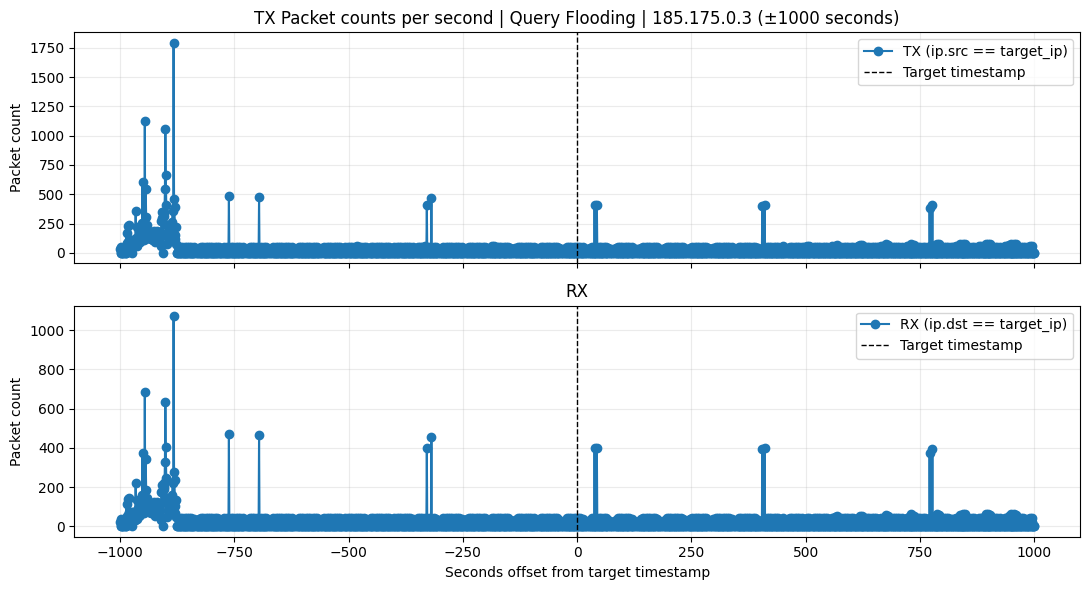

Attack name: Query Flooding
Input CSV: ../train/chunks/csc_9.csv
Input rows: 1000000
Rows for IP 185.175.0.3: 981620
Window: 2023-03-18 20:19:05.019000 -> 2023-03-18 20:52:25.019000
Rows in ±1000 second window: 96114
Time offset applied: 10800 seconds
Metric: Packet counts per second
Target timestamp: 2023-03-18 20:35:45.019000
Window start in data: 2023-03-18 20:19:05.109796047
Window end in data:   2023-03-18 20:52:21.630111933
Nearest packet for this IP:
aligned_ts               2023-03-18 20:35:43.961415052
frame.time_epoch                     1679160943.961415
ip.src                                     185.175.0.3
ip.dst                                     185.175.0.5
frame.len                                           66
modbus.func_code                                   NaN
modbus.exception_code                              NaN
Absolute time delta (s): 1.057585
TX packet total: 56213
RX packet total: 39901
TX peak per second: 1792
RX peak per second: 1072


/tmp/ipykernel_320008/672082524.py:20: DtypeWarning: Columns (0: mbtcp.trans_id, 1: mbtcp.unit_id, 2: mbtcp.len, 3: mbtcp.prot_id, 4: modbus.func_code, 5: modbus.reference_num, 6: modbus.regnum16, 7: modbus.bitnum, 8: modbus.word_cnt, 9: modbus.bit_cnt, 10: modbus.regval_uint16) have mixed types. Specify dtype option on import or set low_memory=False.
  combined = pd.read_csv(input_path)


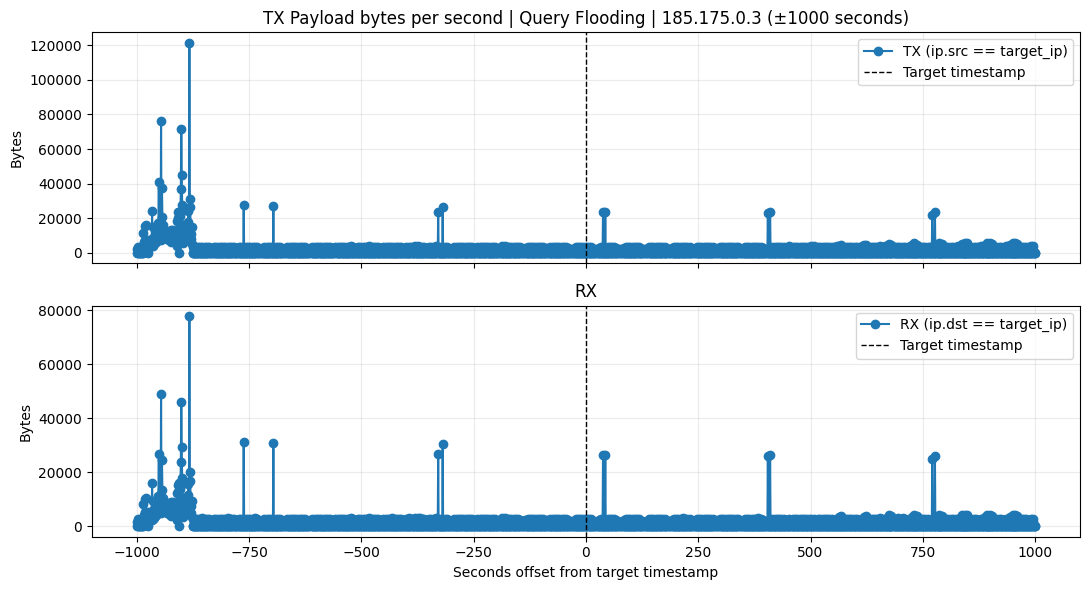

Attack name: Query Flooding
Input CSV: ../train/chunks/csc_9.csv
Input rows: 1000000
Rows for IP 185.175.0.3: 981620
Window: 2023-03-18 20:19:05.019000 -> 2023-03-18 20:52:25.019000
Rows in ±1000 second window: 96114
Time offset applied: 10800 seconds
Metric: Payload bytes per second
Target timestamp: 2023-03-18 20:35:45.019000
Window start in data: 2023-03-18 20:19:05.109796047
Window end in data:   2023-03-18 20:52:21.630111933
Nearest packet for this IP:
aligned_ts               2023-03-18 20:35:43.961415052
frame.time_epoch                     1679160943.961415
ip.src                                     185.175.0.3
ip.dst                                     185.175.0.5
frame.len                                           66
modbus.func_code                                   NaN
modbus.exception_code                              NaN
Absolute time delta (s): 1.057585
TX byte total: 3825266
RX byte total: 2818027
TX peak bytes per second: 121312
RX peak bytes per second: 77852


/tmp/ipykernel_320008/672082524.py:20: DtypeWarning: Columns (0: mbtcp.trans_id, 1: mbtcp.unit_id, 2: mbtcp.len, 3: mbtcp.prot_id, 4: modbus.func_code, 5: modbus.reference_num, 6: modbus.regnum16, 7: modbus.bitnum, 8: modbus.word_cnt, 9: modbus.bit_cnt, 10: modbus.regval_uint16) have mixed types. Specify dtype option on import or set low_memory=False.
  combined = pd.read_csv(input_path)


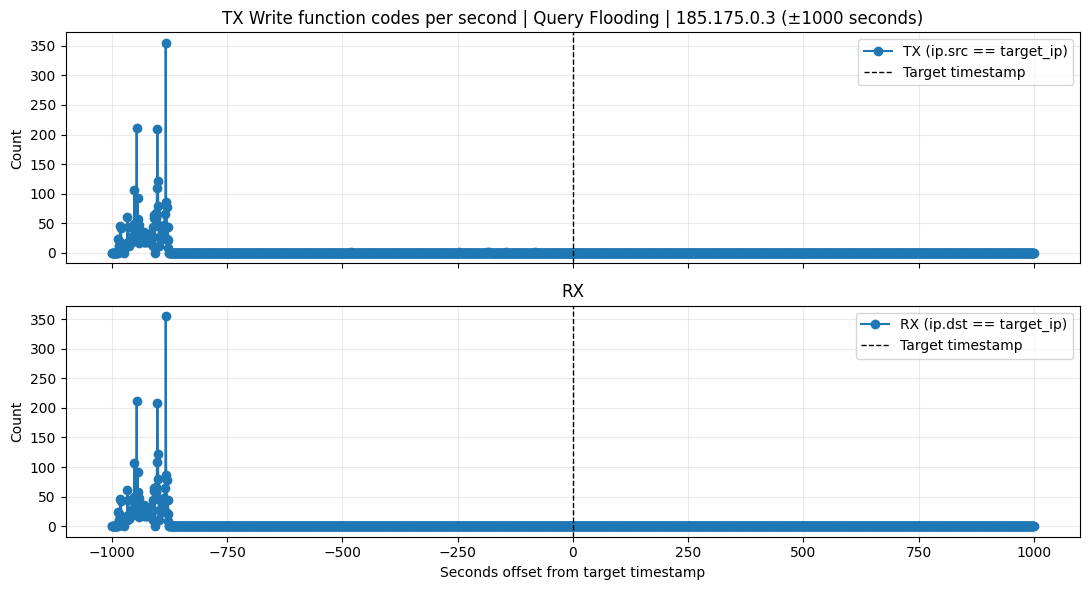

Attack name: Query Flooding
Input CSV: ../train/chunks/csc_9.csv
Input rows: 1000000
Rows for IP 185.175.0.3: 981620
Window: 2023-03-18 20:19:05.019000 -> 2023-03-18 20:52:25.019000
Rows in ±1000 second window: 96114
Time offset applied: 10800 seconds
Metric: Write function codes per second
Target timestamp: 2023-03-18 20:35:45.019000
Window start in data: 2023-03-18 20:19:05.109796047
Window end in data:   2023-03-18 20:52:21.630111933
Nearest packet for this IP:
aligned_ts               2023-03-18 20:35:43.961415052
frame.time_epoch                     1679160943.961415
ip.src                                     185.175.0.3
ip.dst                                     185.175.0.5
frame.len                                           66
modbus.func_code                                   NaN
modbus.exception_code                              NaN
Absolute time delta (s): 1.057585
Write function codes in data: [5, 6, 15, 16]
TX write-code total: 4131
RX write-code total: 4131
Unique write co

/tmp/ipykernel_320008/672082524.py:20: DtypeWarning: Columns (0: mbtcp.trans_id, 1: mbtcp.unit_id, 2: mbtcp.len, 3: mbtcp.prot_id, 4: modbus.func_code, 5: modbus.reference_num, 6: modbus.regnum16, 7: modbus.bitnum, 8: modbus.word_cnt, 9: modbus.bit_cnt, 10: modbus.regval_uint16) have mixed types. Specify dtype option on import or set low_memory=False.
  combined = pd.read_csv(input_path)


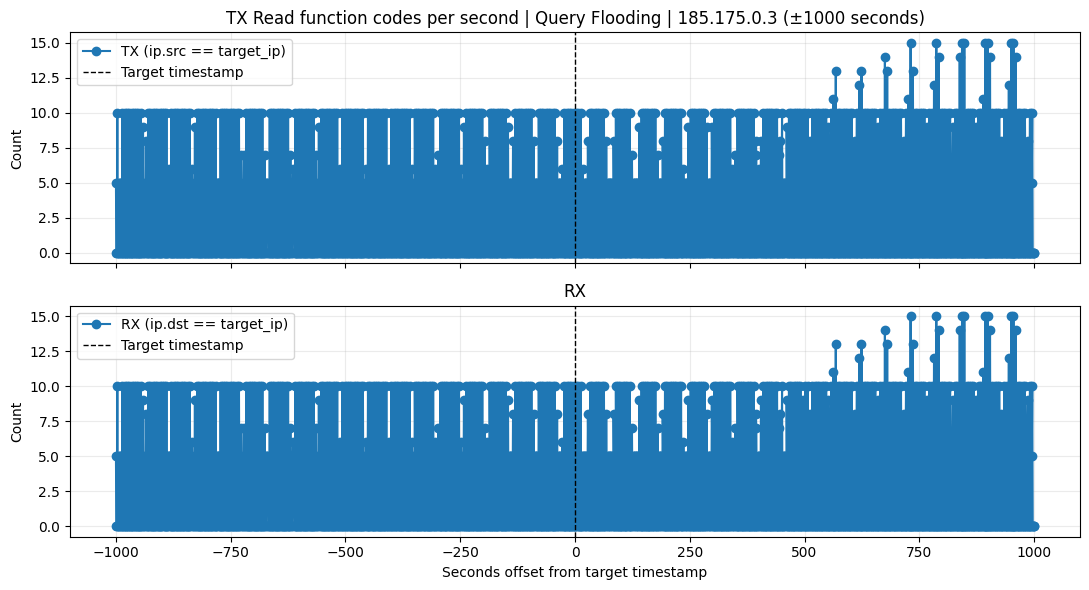

Attack name: Query Flooding
Input CSV: ../train/chunks/csc_9.csv
Input rows: 1000000
Rows for IP 185.175.0.3: 981620
Window: 2023-03-18 20:19:05.019000 -> 2023-03-18 20:52:25.019000
Rows in ±1000 second window: 96114
Time offset applied: 10800 seconds
Metric: Read function codes per second
Target timestamp: 2023-03-18 20:35:45.019000
Window start in data: 2023-03-18 20:19:05.109796047
Window end in data:   2023-03-18 20:52:21.630111933
Nearest packet for this IP:
aligned_ts               2023-03-18 20:35:43.961415052
frame.time_epoch                     1679160943.961415
ip.src                                     185.175.0.3
ip.dst                                     185.175.0.5
frame.len                                           66
modbus.func_code                                   NaN
modbus.exception_code                              NaN
Absolute time delta (s): 1.057585
Read function codes in data: [1, 2, 3, 4]
TX read-code total: 5885
RX read-code total: 5885
Unique read codes pre

/tmp/ipykernel_320008/672082524.py:20: DtypeWarning: Columns (0: mbtcp.trans_id, 1: mbtcp.unit_id, 2: mbtcp.len, 3: mbtcp.prot_id, 4: modbus.func_code, 5: modbus.reference_num, 6: modbus.regnum16, 7: modbus.bitnum, 8: modbus.word_cnt, 9: modbus.bit_cnt, 10: modbus.regval_uint16) have mixed types. Specify dtype option on import or set low_memory=False.
  combined = pd.read_csv(input_path)


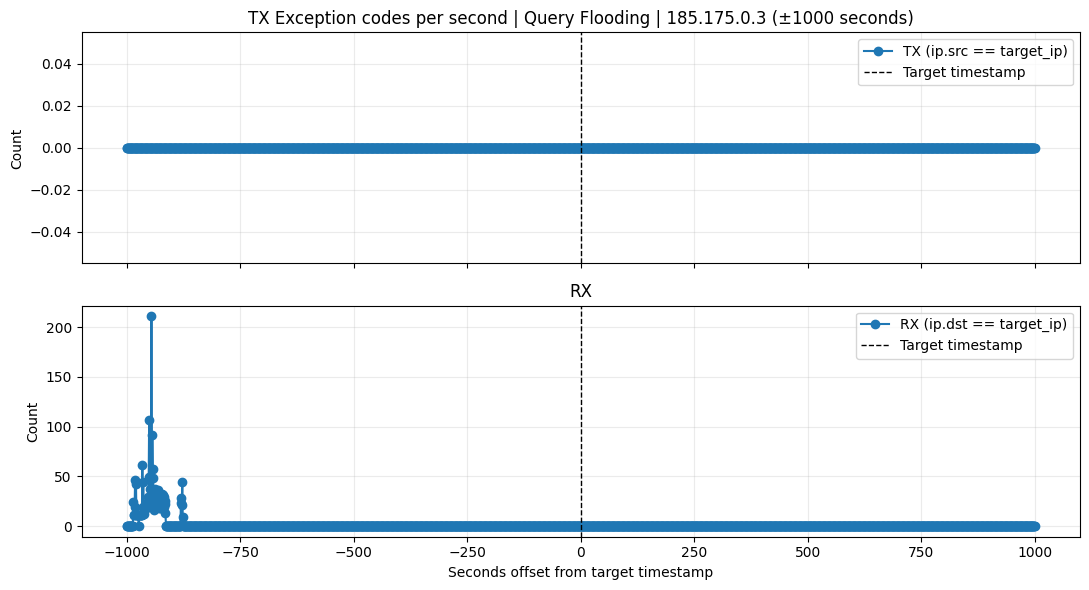

Attack name: Query Flooding
Input CSV: ../train/chunks/csc_9.csv
Input rows: 1000000
Rows for IP 185.175.0.3: 981620
Window: 2023-03-18 20:19:05.019000 -> 2023-03-18 20:52:25.019000
Rows in ±1000 second window: 96114
Time offset applied: 10800 seconds
Metric: Exception codes per second
Target timestamp: 2023-03-18 20:35:45.019000
Window start in data: 2023-03-18 20:19:05.109796047
Window end in data:   2023-03-18 20:52:21.630111933
Nearest packet for this IP:
aligned_ts               2023-03-18 20:35:43.961415052
frame.time_epoch                     1679160943.961415
ip.src                                     185.175.0.3
ip.dst                                     185.175.0.5
frame.len                                           66
modbus.func_code                                   NaN
modbus.exception_code                              NaN
Absolute time delta (s): 1.057585
TX exception total: 0
RX exception total: 2125
Unique exception codes present: [3.0]


/tmp/ipykernel_320008/672082524.py:20: DtypeWarning: Columns (0: mbtcp.trans_id, 1: mbtcp.unit_id, 2: mbtcp.len, 3: mbtcp.prot_id, 4: modbus.func_code, 5: modbus.reference_num, 6: modbus.regnum16, 7: modbus.bitnum, 8: modbus.word_cnt, 9: modbus.bit_cnt, 10: modbus.regval_uint16) have mixed types. Specify dtype option on import or set low_memory=False.
  combined = pd.read_csv(input_path)


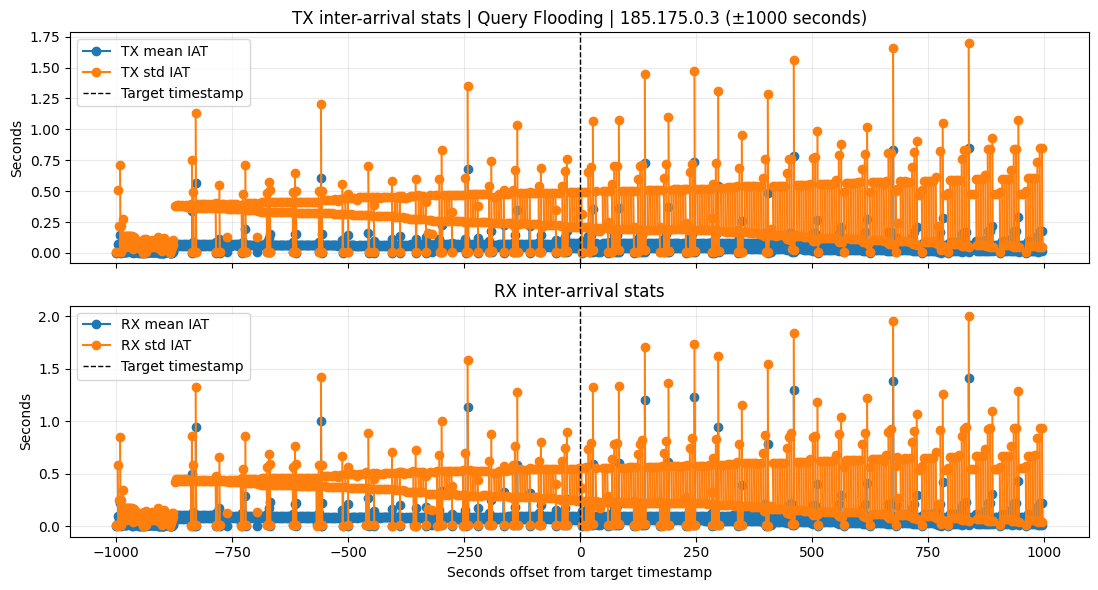

Attack name: Query Flooding
Input CSV: ../train/chunks/csc_9.csv
Input rows: 1000000
Rows for IP 185.175.0.3: 981620
Window: 2023-03-18 20:19:05.019000 -> 2023-03-18 20:52:25.019000
Rows in ±1000 second window: 96114
Time offset applied: 10800 seconds
Metric: Inter-arrival time statistics
Target timestamp: 2023-03-18 20:35:45.019000
Window start in data: 2023-03-18 20:19:05.109796047
Window end in data:   2023-03-18 20:52:21.630111933
Nearest packet for this IP:
aligned_ts               2023-03-18 20:35:43.961415052
frame.time_epoch                     1679160943.961415
ip.src                                     185.175.0.3
ip.dst                                     185.175.0.5
frame.len                                           66
modbus.func_code                                   NaN
modbus.exception_code                              NaN
Absolute time delta (s): 1.057585
TX IAT count: 56212
RX IAT count: 39900
TX IAT mean: 0.035518
TX IAT std: 0.311909
RX IAT mean: 0.050038
RX IAT st

In [7]:
# wrapper(
#     input_csv = "../train/chunks/csc_9.csv", 
#     ip_address = "185.175.0.5", 
#     timestamp = "2023-03-18 20:35:45.019", 
#     attack_name = "Query Flooding",
#     time_range_seconds = 1000, 
#     debug = True, 
#     time_offset_seconds = 10800
# )
wrapper(
    input_csv = "../train/chunks/csc_9.csv", 
    ip_address = "185.175.0.3", 
    timestamp = "2023-03-18 20:35:45.019", 
    attack_name = "Query Flooding",
    time_range_seconds = 1000, 
    debug = True, 
    time_offset_seconds = 10800
)